# Lab 4: Enhancing the Bike Sharing System

Welcome to **Lab 4** of the Modeling & Simulation course! In this laboratory session, we will build upon the foundations laid in the previous labs to enhance our bike-sharing system simulation. This lab introduces the concept of **time slot-specific probabilities**, allowing you to model varying bike usage patterns throughout the day. Additionally, you will implement bike maintenance and downtime, develop a rebalancing mechanism, track customer satisfaction, and undertake a **graded assignment** to design and implement a comprehensive simulation project.

---

## Table of Contents

1. [Recap of Previous Labs](#recap)
2. [Introduction to Time Slot-Specific Probabilities](#time-slots)
   - [Understanding Time Slots](#understanding-time-slots)
3. [Implementing Time Slot-Specific Probabilities](#implementing-time-slots)
   - [Defining Time Slots](#defining-time-slots)
4. [Graded Assignment Overview](#assignment)

---

## <a name="recap"></a>1. Recap of Previous Labs

### Lab 1: Python Introduction
- Gained proficiency in Python programming.
- Learned fundamental programming concepts such as variables, data types, control structures, functions, and basic I/O operations.

### Lab 2: Basic Bike Sharing System Modeling
- Developed a simplified bike-sharing system using Python classes.
- Modeled entities such as stations, bikes, and trips.
- Implemented basic trip generation and analyzed system behavior over a short period.

### Lab 3: Introduction to SimPy
- Introduced SimPy, a discrete-event simulation library in Python.
- Reimplemented the bike-sharing system using SimPy constructs like environments, processes, and resources.
- Explored extensions including variable trip durations, rebalancing strategies, and customer satisfaction tracking.

---

## <a name="time-slots"></a>2. Introduction to Time Slot-Specific Probabilities

In real-world scenarios, bike usage varies throughout the day. To simulate this variability, we introduce **time slot-specific probabilities**. This enhancement allows the simulation to reflect different demand levels during various periods, such as morning rush hours and midday.

### <a name="understanding-time-slots"></a>Understanding Time Slots

- **Time Slots:** Defined periods within a day where bike trip probabilities differ.
- **Recurring Pattern:** Time slots repeat every simulated day, enabling multi-day simulations.
- **Example Time Slots:**
  - **Morning Start (0-120 minutes):** Initial hours with increasing demand.
  - **Midday (120-720 minutes):** Peak hours with stable high demand.

### <a name="mapping-time"></a>Mapping Simulation Time to Real-Time

To create realistic simulations, map simulation minutes to actual day times.

- **Simulation Start Time:** 6:00 AM
- **Morning Start:** 6:00 AM - 8:00 AM (0-120 minutes)
- **Midday:** 8:00 AM - 6:00 PM (120-720 minutes)
- **Simulation Duration:** 20 days (12 hours/day) → 14400 minutes

---

## <a name="implementing-time-slots"></a>3. Implementing Time Slot-Specific Probabilities

### <a name="defining-time-slots"></a>Defining Time Slots

Define time slots with specific trip probability matrices within a single day. Use the modulo operation to map the current simulation time to the appropriate time slot.

```python
# Define time slots for a single day
time_slots = [
    {
        'name': 'morning_start',
        'start': 0,       # 0 minutes into the day (6:00 AM)
        'end': 120,       # 2 hours
        'prob_matrix': {
            ('A', 'B'): 0.4,
            ('B', 'A'): 0.6,
            ('A', 'C'): 0.2,
            ('C', 'A'): 0.5,
            ('B', 'C'): 0.3,
            ('C', 'B'): 0.4,
            ('A', 'D'): 0.3,
            ('D', 'A'): 0.2,
        }
    },
    {
        'name': 'midday',
        'start': 120,      # 2 hours into the day (8:00 AM)
        'end': 720,        # 12 hours total (6:00 PM)
        'prob_matrix': {
            ('A', 'B'): 0.2,
            ('B', 'A'): 0.3,
            ('A', 'C'): 0.1,
            ('C', 'A'): 0.2,
            ('B', 'C'): 0.25,
            ('C', 'B'): 0.35,
            ('A', 'D'): 0.15,
            ('D', 'A'): 0.25,
        }
    }
    # Add more time slots if needed
]

# Define default probability matrix if no slot matches
default_prob_matrix = {
    ('A', 'B'): 0.05,
    ('B', 'A'): 0.05,
    ('A', 'C'): 0.05,
    ('C', 'A'): 0.05,
    ('B', 'C'): 0.05,
    ('C', 'B'): 0.05,
    ('A', 'D'): 0.05,
    ('D', 'A'): 0.05,
}


In [63]:
# Start from the code you've implemented in lab 3, add time-slot specific probabilities below



## <a name="assignment"></a>Graded Assignment Overview

Design and implement an enhanced bike-sharing system simulation using **SimPy**, incorporating advanced features to model a realistic and complex environment. Your simulation should build upon the concepts learned in previous labs and include the following components:

---

Your simulation must include the following elements:

### 1. Multiple Stations:

- **Minimum of Four stations** with varying capacities and initial bike counts.
- Each station should have a unique name, capacity, and initial number of bikes.

### 2. Time-Dependent Trip Probabilities:

- Implement trip probabilities that change based on different time slots (e.g., morning start, midday).
- Define at least **two distinct time slots** with different probability matrices.
- Ensure that time slots are **recurring daily** over the simulation period.

### 3. Bike Maintenance and Downtime:

- Model bike failures with a specified failure probability during trips.
- Implement a repair process that handles broken bikes, making them unavailable until repaired. The implementation details are up to your imagination.
- Track and report the number of bikes under maintenance.

### 4. Rebalancing Mechanism:

- Develop a rebalancing strategy to redistribute bikes between stations based on current demand and bike levels.
- Rebalancing should occur at regular intervals (e.g., every 20 minutes) and follow defined criteria.

### 5. Customer Satisfaction Tracking:

- Track the number of **unhappy customers** who cannot rent a bike due to unavailability.
- Track the number of **unhappy customers** who cannot return a bike due to full stations.

### 6. Data Collection and Visualization:

- Collect data on **bike levels** at each station over time.
- Collect data on **broken bikes** and maintenance activities.
- Collect data on **customer satisfaction** metrics.
- Generate plots to visualize:
  - **Bike levels** at each station over time.
  - **Number of bikes under maintenance**.
  - **Customer satisfaction metrics** (e.g., unhappy customers over time).

### 7. Simulation:

- Allow the simulation to run for a configurable duration (e.g., **20 days**).
- Parameters such as the number of stations, capacities, initial bikes, trip probabilities, maintenance rates, rebalancing intervals, and simulation duration should be easily adjustable.
- Simulate and observe the system with various parameters.

---

#### (Optional) Money Earning Mechanism:

- Introduce a system where the bike-sharing service earns **money based on bike rentals** (e.g., per hour rented).
- Track and report **total earnings** over the simulation period.

## What to Look For in Your Simulations

The primary objective of this lab is to enable you to create a realistic and dynamic simulation of a bike-sharing system that accounts for daily usage patterns, system maintenance, and operational strategies. Things to look for:

* Bike Availability: Assess how well the rebalancing mechanism maintains adequate bike levels across stations.
* Maintenance Impact: Evaluate the effect of bike failures on system performance and customer satisfaction.
* Customer Satisfaction: Analyze the number of unhappy customers and identify patterns or causes.

Write down a couple of observations from your simulations to accompany the presentation of your system.

## Grading

You will present your work in the upcoming laboratory, showing your system implementation and 1-3 simulations that you ran. The simulations should be accompanied by visual plots and you are encouraged to present any interesting observations about your system (e.g. with environment setup X the customer dissatisfaction drops significantly when increasing the rebalancing frequency to value y).

The project grade will be determined by the grade of completion of your system (how much of the project task has been implemented), as well as your understanding of it. The latter will be assessed through some basic questions about your model/system/simulations.

*Note: Where not strongly specified, you are free to design a subsystem/idea however you find best fit, e.g. points 2, 3 and 4 can have many different subsystem designs. There is no one correct way to do it.

In [64]:
# librarii necesare
import simpy
import random
import matplotlib.pyplot as plt

In [65]:
# Defining the Station Class
class Station:
    def __init__(self, env, name, capacity, init_bikes):
        self.env = env
        self.name = name
        self.capacity = capacity
        self.bikes = simpy.Container(env, init=init_bikes, capacity=capacity)

In [66]:
env = simpy.Environment()

In [67]:
# Cerinta 1 -> 4 statii diferite

stationOne = Station(env, "Station One", 20, 10)
stationTwo = Station(env, "Station Two", 15, 5)
stationThree = Station(env, "Station Three", 25, 10)
stationFour = Station(env, "Station Four", 30, 15)

stations = [stationOne, stationTwo, stationThree, stationFour]

In [68]:
# Cerinta 2 -> Matricea de probabilitati pentru fiecare interval orar

# Folosim aceasta variabila pentru a afla in ce interval orar ne aflam
MIN_PER_DAY = 1440  

# Define time slots for a single day
time_slots = [
    {
        'name': 'morning_start',
        'start': 0,       # 0 minutes into the day (6:00 AM)
        'end': 240,       # 4 hours
        'prob_matrix': {
            (stationOne, stationTwo): 0.4,
            (stationTwo, stationOne): 0.3,
            (stationOne, stationThree): 0.2,
            (stationThree, stationOne): 0.3,
            (stationTwo, stationThree): 0.25,
            (stationThree, stationTwo): 0.2,
            (stationOne, stationFour): 0.3,
            (stationFour, stationOne): 0.2,
            (stationTwo, stationFour): 0.2,
            (stationFour, stationTwo): 0.25,
            (stationThree, stationFour): 0.3,
            (stationFour, stationThree): 0.35
        }
    },
    {
        'name': 'midday',
        'start': 240,      # 4 hours into the day (10:00 AM)
        'end': 600,        # 6 hours total (4:00 PM)
        'prob_matrix': {
            (stationOne, stationTwo): 0.2,
            (stationTwo, stationOne): 0.25,
            (stationOne, stationThree): 0.15,
            (stationThree, stationOne): 0.2,
            (stationTwo, stationThree): 0.2,
            (stationThree, stationTwo): 0.15,
            (stationOne, stationFour): 0.25,
            (stationFour, stationOne): 0.2,
            (stationTwo, stationFour): 0.15,
            (stationFour, stationTwo): 0.2,
            (stationThree, stationFour): 0.2,
            (stationFour, stationThree): 0.25
        }
    },
    {
        'name': 'evening',
        'start': 720,      # 12 hours into the day (6:00 PM)
        'end': 960,        # 4 hours total (10:00 PM)
        'prob_matrix': {
            (stationOne, stationTwo): 0.35,
            (stationTwo, stationOne): 0.3,
            (stationOne, stationThree): 0.25,
            (stationThree, stationOne): 0.3,
            (stationTwo, stationThree): 0.3,
            (stationThree, stationTwo): 0.25,
            (stationOne, stationFour): 0.2,
            (stationFour, stationOne): 0.35,
            (stationTwo, stationFour): 0.3,
            (stationFour, stationTwo): 0.25,
            (stationThree, stationFour): 0.2,
            (stationFour, stationThree): 0.3
        }
    }
]

# Define default probability matrix if no slot matches
default_prob_matrix = {
    (stationOne, stationTwo): 0.1,
    (stationTwo, stationOne): 0.1,
    (stationOne, stationThree): 0.1,
    (stationThree, stationOne): 0.1,
    (stationTwo, stationThree): 0.1,
    (stationThree, stationTwo): 0.1,
    (stationOne, stationFour): 0.1,
    (stationFour, stationOne): 0.1,
    (stationTwo, stationFour): 0.1,
    (stationFour, stationTwo): 0.1,
    (stationThree, stationFour): 0.1,
    (stationFour, stationThree): 0.1
}

In [ ]:
# Cerinta 3 -> Daca se strica bicicletele in timpul calatoriei

BREAKDOWN_PROB = 0.01  # Probabilitatea ca o bicicleta sa se strice in timpul calatoriei (adjusted to realistic value)
REPAIR_TIME = 30       # Timpul necesar pentru repararea unei biciclete stricate -> in minute


bikes_under_repair = []  # List for tracking bikes under repair over time

In [74]:
# da track la cate biciclete exista in fiecare statie la fiecare minut
def monitor_stations(env, stations, bike_levels):
    while True:
        for station in stations:
            bike_levels[station.name].append((env.now, station.bikes.level))
        yield env.timeout(1)

In [76]:
# vom face o functie care ne va returna matricea de probabilitati in functie de intervalul orar in care ne aflam

def get_current_prob_matrix(current_time):
    time_in_day = current_time % MIN_PER_DAY

    for slot in time_slots:
        if slot['start'] <= time_in_day < slot['end']:
            return slot['prob_matrix']

    return default_prob_matrix


In [78]:
# Alternative rebalancing: proportional multi-source/multi-sink with hysteresis
# Moves bikes from stations with surplus to those with deficit based on a target fill ratio.
# Distinct from the fullest->emptiest fixed-move strategy.

def rebalance_process_proportional(
    env,
    stations,
    check_interval=20,           # minutes
    target_fill_ratio=0.55,      # desired average fill vs. capacity
    slack_band=0.10,             # avoid oscillation; act only outside +/- slack
    max_total_moves=8            # cap total bike moves per cycle
):
    def current_level(s):
        return int(s.bikes.level)

    def capacity(s):
        return int(s.bikes.capacity)

    while True:
        # Compute per-station targets
        targets = {s: int(round(target_fill_ratio * capacity(s))) for s in stations}

        # Classify surplus and deficit using hysteresis band
        surplus_list = []  # (station, extra)
        deficit_list = []  # (station, need)
        for s in stations:
            lvl = current_level(s)
            cap = capacity(s)
            band = int(round(slack_band * cap))
            tgt = targets[s]
            if lvl > tgt + band:
                surplus_list.append((s, lvl - (tgt + band)))
            elif lvl < tgt - band:
                deficit_list.append((s, (tgt - band) - lvl))

        # Sort: large surplus first, large deficit first
        surplus_list.sort(key=lambda x: x[1], reverse=True)
        deficit_list.sort(key=lambda x: x[1], reverse=True)

        moves_done = 0
        # Greedy distribution across multiple sources/sinks
        for src_idx, (src, extra) in enumerate(list(surplus_list)):
            if moves_done >= max_total_moves:
                break
            if extra <= 0:
                continue

            # Try to satisfy deficits in order
            for dst_idx, (dst, need) in enumerate(list(deficit_list)):
                if moves_done >= max_total_moves or extra <= 0:
                    break
                if need <= 0 or src is dst:
                    continue

                # Plan how many to move this pairing
                pair_moves = min(extra, need, max_total_moves - moves_done)
                if pair_moves <= 0:
                    continue

                # Execute unit moves to stay consistent with simpy Container semantics
                for _ in range(pair_moves):
                    yield src.bikes.get(1)
                    yield dst.bikes.put(1)
                    moves_done += 1
                    extra -= 1
                    need -= 1

                # Update local views
                surplus_list[src_idx] = (src, extra)
                deficit_list[dst_idx] = (dst, need)

        # Optional: compact log line
        if moves_done > 0:
            # Summarize station levels after rebalancing
            summary = ", ".join([f"{s.name}:{int(s.bikes.level)}/{int(s.bikes.capacity)}" for s in stations])
            print(f"Time {env.now}: Proportional rebalance executed, moves={moves_done}. Levels: {summary}")

        # Wait until next cycle
        yield env.timeout(check_interval)


In [79]:
# Canonical logic overrides (consistent with idk.txt) + unhappy customer tracking
import random

# Globals
current_broken_bike = 0
unhappy_rent = []      # (time, count)
unhappy_return = []    # (time, count)

# Repair process: increments the global counter; returns bike after repair
def repair_bike_process(env, from_station, to_station, repair_time):
    global current_broken_bike
    current_broken_bike += 1
    print(f"Time {env.now}: Bike broke between {from_station.name} -> {to_station.name} (under repair)")
    yield env.timeout(repair_time)
    # Try return to destination, else origin, else drop
    if to_station.bikes.level < to_station.capacity:
        yield to_station.bikes.put(1)
        print(f"Time {env.now}: Repaired bike returned to {to_station.name}")
    elif from_station.bikes.level < from_station.capacity:
        yield from_station.bikes.put(1)
        print(f"Time {env.now}: Repaired bike returned to {from_station.name}")
    else:
        print(f"Time {env.now}: Repaired bike couldn't be placed (both full).")
    current_broken_bike -= 1

# Trip: returns unhappy statistics
def bike_trip(env, from_station, to_station, trip_duration, breakdown_prob, repair_time):
    # unhappy rent if no bikes
    if from_station.bikes.level <= 0:
        unhappy_rent.append((env.now, 1))
        print(f"Time {env.now}: No bikes at {from_station.name} -> trip cancelled")
        return

    yield from_station.bikes.get(1)
    print(f"Time {env.now}: Bike taken from {from_station.name}")

    # simulate travel
    yield env.timeout(trip_duration)

    # breakdown: schedule repair, do not place at dest
    if random.random() < breakdown_prob:
        env.process(repair_bike_process(env, from_station, to_station, repair_time))
        return

    # normal return with fallback
    if to_station.bikes.level < to_station.capacity:
        yield to_station.bikes.put(1)
        print(f"Time {env.now}: Bike returned to {to_station.name}")
    else:
        # destination full -> attempt origin after extra time
        unhappy_return.append((env.now, 1))
        print(f"Time {env.now}: Destination {to_station.name} full, attempting to return to {from_station.name}")
        yield env.timeout(trip_duration)
        if from_station.bikes.level < from_station.capacity:
            yield from_station.bikes.put(1)
            print(f"Time {env.now}: Bike returned to {from_station.name} (fallback)")
        else:
            print(f"Time {env.now}: Both stations full -> bike lost (model simplification)")

# Time-aware trip generation
def generate_trips(env, time_slots_fn, stations):
    while True:
        prob_matrix = time_slots_fn(env.now)
        for (from_s, to_s), prob in prob_matrix.items():
            if prob <= 0:
                continue
            if random.random() < prob:
                trip_duration = random.randint(3, 7)
                env.process(bike_trip(env, from_s, to_s, trip_duration, BREAKDOWN_PROB, REPAIR_TIME))
        yield env.timeout(1)

# Monitor: bikes under repair
def monitor_broken_bikes(env, bikes_under_repair_log, sample_interval=1):
    while True:
        count = int(current_broken_bike)
        print(f"Time {env.now}: Bikes under repair: {count}")
        bikes_under_repair_log.append((env.now, count))
        yield env.timeout(sample_interval)

# Plot unhappy customers helper
def plot_unhappy_customers(unhappy_rent_log, unhappy_return_log):
    if not unhappy_rent_log and not unhappy_return_log:
        print("No data recorded for unhappy customers.")
        return
    # aggregate by minute
    from collections import Counter
    rent_counter = Counter(t for t, _ in unhappy_rent_log)
    return_counter = Counter(t for t, _ in unhappy_return_log)
    minutes = sorted(set(rent_counter.keys()) | set(return_counter.keys()))
    rent_series = [rent_counter.get(m, 0) for m in minutes]
    return_series = [return_counter.get(m, 0) for m in minutes]
    plt.figure(figsize=(10,3))
    plt.plot(minutes, rent_series, '-o', color='blue', markersize=3, label='Unhappy Rent')
    plt.plot(minutes, return_series, '-o', color='orange', markersize=3, label='Unhappy Return')
    plt.xlabel('Time (minutes)')
    plt.ylabel('Unhappy events')
    plt.title('Unhappy customers over time')
    plt.legend()
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()


In [ ]:
#Simulation Setup

# Reinitialize the bike_levels dictionary
bike_levels = {station.name: [] for station in stations}

# Start the monitoring process
env.process(generate_trips(env, get_current_prob_matrix, stations))
env.process(monitor_stations(env, stations, bike_levels))
# Use the alternative proportional rebalancing
env.process(rebalance_process_proportional(env, stations))
env.process(monitor_broken_bikes(env, bikes_under_repair))

env.run(until=(MIN_PER_DAY * 1))  # Simulate for 1 day (1440 minutes)


Time 0: Bikes under repair: 0
Time 0: Bike taken from Station Two
Time 0: Bike taken from Station Three
Time 0: Bike taken from Station Four
Time 1: Bikes under repair: 0
Time 1: Bike taken from Station One
Time 1: Bike taken from Station Four
Time 1: Bike taken from Station Three
Time 1: Bike taken from Station Four
Time 2: Bikes under repair: 0
Time 2: Bike taken from Station Two
Time 2: Bike taken from Station Four
Time 3: Bikes under repair: 0
Time 3: Bike returned to Station Two
Time 3: Bike taken from Station One
Time 3: Bike taken from Station Three
Time 3: Bike taken from Station Two
Time 3: Bike taken from Station Two
Time 3: Bike taken from Station Four
Time 3: Bike taken from Station Three
Time 4: Bikes under repair: 0
Time 4: Bike taken from Station One
Time 4: Bike taken from Station Four
Time 4: Bike taken from Station Four
Time 5: Bikes under repair: 0
Time 5: Bike taken from Station Four
Time 5: Bike taken from Station Four
Time 6: Bikes under repair: 0
Time 6: Bike ret

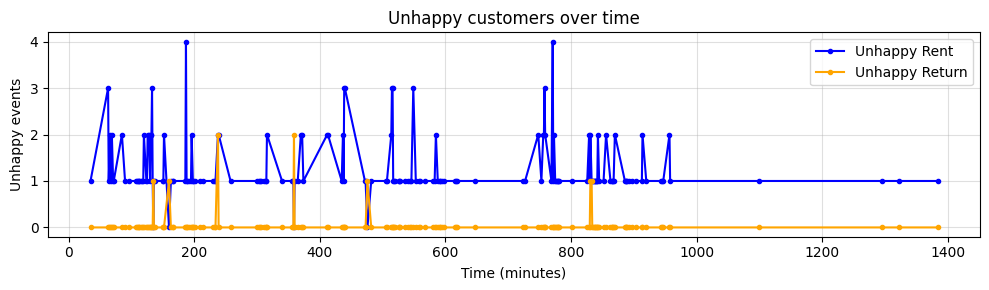

In [81]:
# Plot unhappy customers
plot_unhappy_customers(unhappy_rent, unhappy_return)


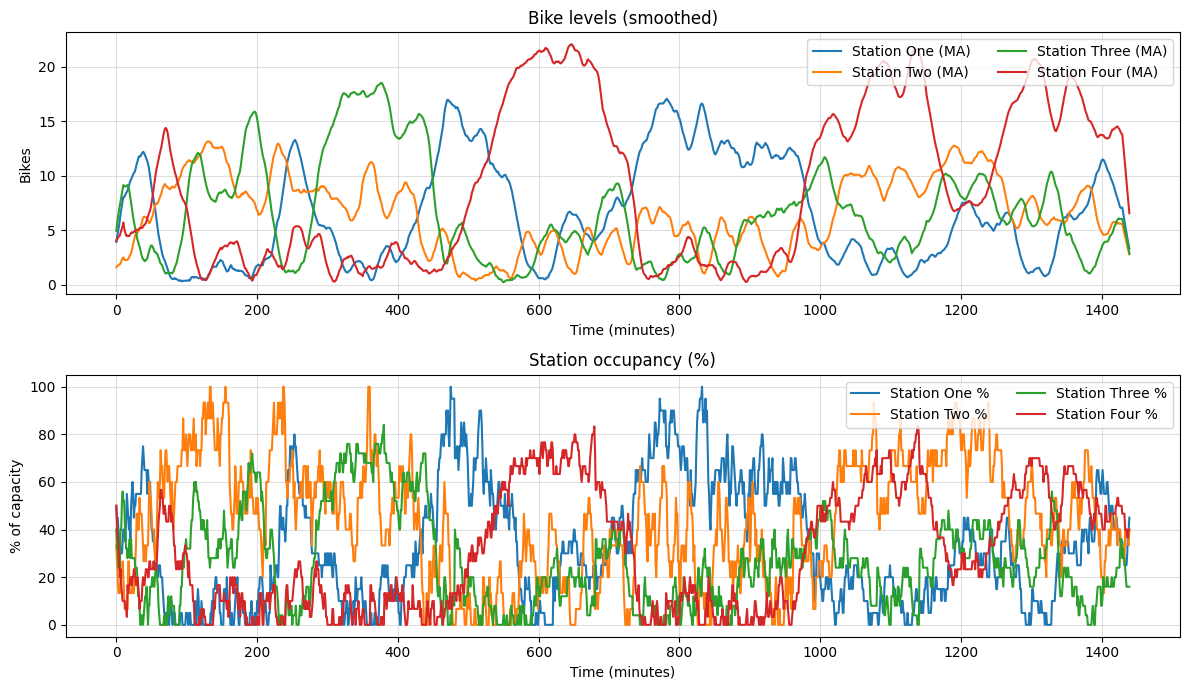

In [82]:
# Plotting Results (distinct style): moving average + occupancy
import numpy as np

# Build aligned time grid (minutes) for the full simulated day
T = MIN_PER_DAY
minutes = list(range(T))
station_to_series = {name: [np.nan]*T for name in bike_levels.keys()}

# Fill per-station minute-level counts; forward-fill missing values
for station_name, levels in bike_levels.items():
    last = None
    for t, count in levels:
        if 0 <= t < T:
            station_to_series[station_name][t] = count
            last = count
    # forward-fill
    if last is None:
        last = 0
    run = last
    for t in range(T):
        if np.isnan(station_to_series[station_name][t]):
            station_to_series[station_name][t] = run
        else:
            run = station_to_series[station_name][t]

# Helper: simple moving average
def moving_average(x, window=15):
    if window <= 1:
        return x
    c = np.convolve(x, np.ones(window)/window, mode='same')
    return c

plt.figure(figsize=(12, 7))
# Top subplot: smoothed lines
ax1 = plt.subplot(2,1,1)
for name, series in station_to_series.items():
    smoothed = moving_average(np.array(series), window=21)
    ax1.plot(minutes, smoothed, label=f"{name} (MA)")
ax1.set_title("Bike levels (smoothed)")
ax1.set_xlabel("Time (minutes)")
ax1.set_ylabel("Bikes")
ax1.grid(alpha=0.4)
ax1.legend(loc='upper right', ncol=2)

# Bottom subplot: occupancy percentage
ax2 = plt.subplot(2,1,2)
for s in stations:
    series = station_to_series[s.name]
    pct = (np.array(series) / float(s.bikes.capacity)) * 100.0
    ax2.plot(minutes, pct, label=f"{s.name} %")
ax2.set_title("Station occupancy (%)")
ax2.set_xlabel("Time (minutes)")
ax2.set_ylabel("% of capacity")
ax2.grid(alpha=0.4)
ax2.legend(loc='upper right', ncol=2)

plt.tight_layout()
plt.show()

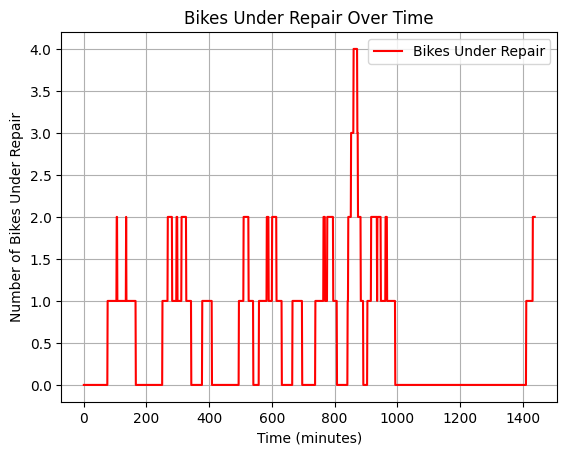

In [83]:
# plot pentru bicicletele stricate
times, broken_counts = zip(*bikes_under_repair)
plt.plot(times, broken_counts, label='Bikes Under Repair', color='red')
plt.xlabel('Time (minutes)')
plt.ylabel('Number of Bikes Under Repair')
plt.title('Bikes Under Repair Over Time')
plt.legend()
plt.grid()
plt.show()